In [16]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 

In [17]:
data = pd.read_csv("https://docs.google.com/spreadsheets/d/1FPvMTkVh4gLZf9PeQSINp3Cif87Qmoc6L8R-8g1FIWk/export?format=csv", header=2)

x = data.iloc[:, :5].to_numpy()
y = data.iloc[:, 5].to_numpy()

# Normalize to improve convergence
x = (x - np.mean(x, axis=0)) / np.std(x, axis=0)

In [18]:
def cost(y,pred):
  return ((pred-y)**2).sum(axis=0) / (2*y.shape[0])

def predict(w, x):
    return w.T @ x

def add_bias(x):
    bias = np.ones((x.shape[0]))
    return np.c_[bias, x]

def update_bobot(w, xb, y, alpha):
    output = predict(w, xb)
    error = output - y
    m = y.shape[0]
    gradient = (xb @ error) / m
    w = w - alpha * gradient
    return w

In [19]:
# Inisialisasi
w = np.zeros(x.shape[1] + 1)
alpha = 0.01
iterasi = 1
xb = add_bias(x)
xb = xb.T

Mulai training
Iterasi 0: Cost = 0.020475
Iterasi 100: Cost = 0.020465
Iterasi 200: Cost = 0.020457
Iterasi 300: Cost = 0.020451
Iterasi 400: Cost = 0.020447
Iterasi 500: Cost = 0.020443
Iterasi 600: Cost = 0.020441
Iterasi 700: Cost = 0.020439
Iterasi 800: Cost = 0.020438
Iterasi 900: Cost = 0.020437


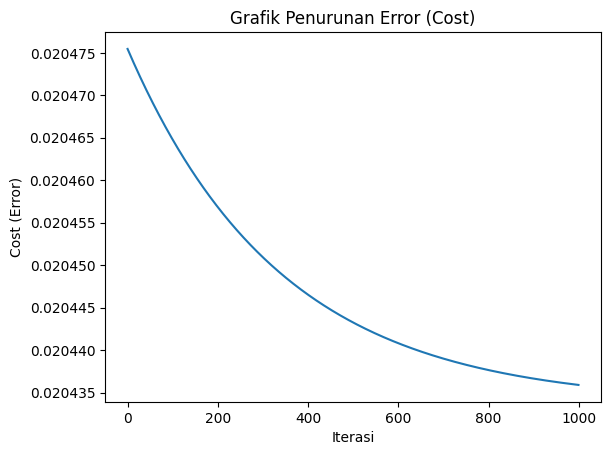

Final Weights (Numpy): [3.64799999 0.07698841 0.0591814  0.06765486 0.05152913 0.02498204]
w = [3.647999994549727, 0.0769884111663676, 0.05918139922690753, 0.06765485718954163, 0.05152912673602119, 0.024982043320601634]


In [71]:
epochs = 1000
cost_history = []

print("Mulai training")
for i in range(epochs):
    w = update_bobot(w, xb, y, alpha)
    output = predict(w, xb)
    c = cost(y, output)
    cost_history.append(c)
    
    if i % 100 == 0:
        print(f"Iterasi {i}: Cost = {c:.6f}")

plt.plot(cost_history)
plt.title("Grafik Penurunan Error (Cost)")
plt.xlabel("Iterasi")
plt.ylabel("Cost (Error)")
plt.show()

print(f"Final Weights (Numpy): {w}")

print(f"w = {w.tolist()}")

In [ ]:
# Analisis Hasil Prediksi
final_output = predict(w, xb)

# Buat DataFrame untuk membandingkan Asli vs Prediksi
df_compare = pd.DataFrame({
    'Actual IPK': y,
    'Predicted IPK': final_output,
    'Selisih': np.abs(y - final_output)
})

print("=== Perbandingan Data Asli vs Prediksi (5 Data Teratas) ===")
print(df_compare.head())

print("\n=== Statistik Selisih (Error) ===")
print(df_compare['Selisih'].describe())

print(f"\nFinal MSE Cost: {cost(y, final_output):.5f}")

# Bobot Fitur (Feature Importance)
feature_names = ["Bias (Intercept)", "Jml Kehadiran", "Jml Jam Tidur", "Jml Jam Scroll socmed", "Jenis Kelamin", "Jml Jam Belajar"]
print("\n=== Bobot Fitur (Pengaruh ke IPK) ===")
print("Bobot positif = Berbanding lurus, Bobot negatif = Berbanding terbalik")
for name, weight in zip(feature_names, w):
    print(f"{name:<25}: {weight:.4f}")